In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from tqdm import tqdm

DATA_PATH = "D:/ML/RSNA2024"

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Data Processing

In [3]:
df = pd.read_csv(os.path.join(DATA_PATH, "test_series_descriptions.csv"))
df.head(10)

,study_id,series_id,series_description
0,44036939,2828203845,Sagittal T1
1,44036939,3481971518,Axial T2
2,44036939,3844393089,Sagittal T2/STIR


In [4]:
allFiles = []

for root, dirs, files in os.walk(os.path.join(DATA_PATH, "test_images")):
    for f in files:
        if f.endswith(".dcm"):
            allFiles.append(os.path.join(root,f))

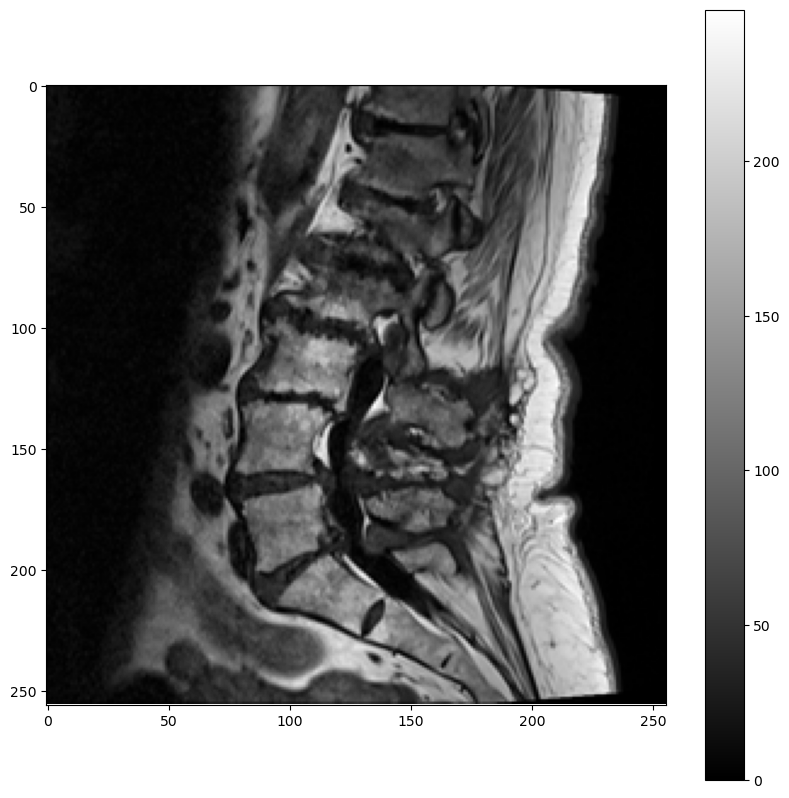

In [5]:

IMG_SIZE = (256, 256)
eps=1e-12

def dicomToArray(path):
    dicom = pydicom.read_file(path)
    data = pydicom.pixel_data_handlers.util.apply_modality_lut(dicom.pixel_array, dicom)
    data = pydicom.pixel_data_handlers.util.apply_windowing(data, dicom)
    # data = dicom.pixel_array
    if dicom.PhotometricInterpretation == "MONOCHROME1":
        data = np.amax(data) - data
        
    w, h = data.shape[0], data.shape[1]

    #Center crop
    if w>h:
        diff = w-h
        data = data[diff//2:diff//2+h, :]
    if h>w:
        diff = h-w
        data = data[:, diff//2:diff//2+w]

    data = data - np.min(data)
    data = data * 1.0/(np.max(data)+eps)

    w, h = data.shape[0], data.shape[1]

    # resize
    if not (w == IMG_SIZE[0] and h == IMG_SIZE[1]):
        data = np.array(Image.fromarray((data * 255).astype(np.uint8), mode="L").resize(IMG_SIZE))

    # data = (data * 255).astype(np.uint8)
    return data


plt.figure(figsize=(10,10))
_ = plt.imshow(dicomToArray(os.path.join(DATA_PATH, "test_images/44036939/2828203845/15.dcm")), cmap="gray")
_ = plt.colorbar()

# plt.figure(figsize=(10,10))
# for i,filePath in enumerate(np.random.choice(allFiles, 9)):
#     plt.subplot(3,3, i+1)
#     _ = plt.imshow(dicomToArray(filePath), cmap="gray")
#     _ = plt.axis("off")
# plt.colorbar()

## Dataset

In [6]:
allFiles[0]

'D:/ML/RSNA2024\\test_images\\44036939\\2828203845\\1.dcm'

In [18]:
X=[]
description=[]
for i,filePath in enumerate(tqdm(allFiles)):
    isTma = False
    parts = filePath.split("\\")
    instance = int(parts[-1].replace(".dcm", ""))
    seriesId = int(parts[-2])
    studyId = int(parts[-3])
        
    im = dicomToArray(filePath)
    
    X.append(im)
    description.append({"seriesId": seriesId, "studyId": studyId})

print(len(X))
print(X[0].shape)

100%|██████████| 97/97 [00:01<00:00, 69.37it/s] 

97
(256, 256)


In [19]:
from torchvision.transforms import v2

transforms = v2.Compose([
    # v2.RandomHorizontalFlip(p=0.5),
    # v2.RandomVerticalFlip(p=0.5),
    v2.Grayscale(3),
    # v2.RandomResizedCrop(IMG_SIZE, (0.2,0.6), (0.8,1.2)),
    v2.Resize(IMG_SIZE),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transformsVal = v2.Compose([
    v2.Grayscale(3),
    v2.Resize(IMG_SIZE),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

data = zip(X, description)


def generator():
    for im, descr in data:
        im = np.expand_dims(im,0)
        im = im.astype(np.float32)/255.0
        im = transforms(torch.Tensor(im))
        yield im, descr


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


tensor(-2.1179) tensor(2.4134)
torch.Size([3, 256, 256])
{'seriesId': 2828203845, 'studyId': 44036939}


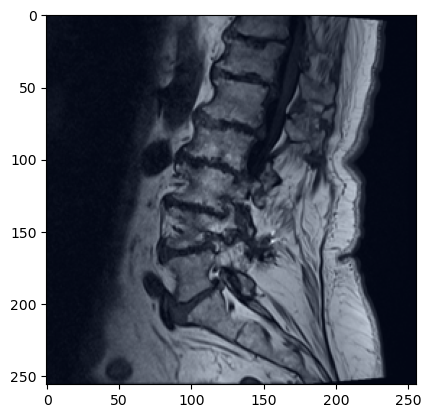

In [22]:
g = generator()
testInstance = next(g)

plt.imshow((torch.moveaxis(testInstance[0], 0,-1)*0.225)+0.485)
print(torch.min(testInstance[0]), torch.max(testInstance[0]))
print(testInstance[0].shape)
print(testInstance[1])

In [12]:
BATCH_SIZE = 16

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(X))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [14]:
for XData in trainLoader:
# for X, targets, targetsE,targetsK,targetsL,targetsS, patIds in trainLoader:
    print(f"Shape of X: {XData.shape} {XData.dtype}")
    print("Max and Min: ", torch.max(XData), torch.min(XData))
    break

Shape of X: torch.Size([16, 3, 256, 256]) torch.float32
Max and Min:  tensor(2.6400) tensor(-2.1179)


## Model

In [89]:
import torchinfo
import timm


model = timm.create_model('edgenext_base', pretrained=True, num_classes=1)
model.name = f"edgenext_base_{IMG_SIZE[0]}"

# model = timm.create_model('resnet34d', pretrained=True, num_classes=len(enc.classes_))
# model.name = "resnet34d_384_wang"

# model = timm.create_model('rexnet_150', pretrained=True, num_classes=len(enc.classes_))
# model.name = "RexNet150"

from torchview import draw_graph

model_graph = draw_graph(model, input_size=(BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)

model = model.to(device)
torchinfo.summary(model, input_size=[BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]])

Layer (type:depth-idx)                                       Output Shape              Param #
EdgeNeXt                                                     [16, 1]                   --
├─Sequential: 1-1                                            [16, 80, 64, 64]          --
│    └─Conv2d: 2-1                                           [16, 80, 64, 64]          3,920
│    └─LayerNorm2d: 2-2                                      [16, 80, 64, 64]          160
├─Sequential: 1-2                                            [16, 584, 8, 8]           --
│    └─EdgeNeXtStage: 2-3                                    [16, 80, 64, 64]          --
│    │    └─Identity: 3-1                                    [16, 80, 64, 64]          --
│    │    └─Sequential: 3-2                                  [16, 80, 64, 64]          157,920
│    └─EdgeNeXtStage: 2-4                                    [16, 160, 32, 32]         --
│    │    └─Sequential: 3-3                                  [16, 160, 32, 32]        

In [90]:
loadExistingModel=False

if loadExistingModel:
    model = model.to(device)
    checkpoint = torch.load(os.path.join("./", "edgenextBase_384_epoch_8.pt"), map_location=device)
    print(model.load_state_dict(checkpoint['model_state_dict']))
    optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)
    # optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1, steps_per_epoch=len(trainLoader), epochs=10)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.01)/100))
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    startEpoch = checkpoint['epoch']
    # startEpoch=0
    # loss = checkpoint['loss']
else:
    startEpoch=0
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(trainLoader), epochs=15)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.1)/500))

In [92]:
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

LOG_INTERVAL=2
epochs = 100
saveModel=False
SAVE_MODEL_INTERVAL=10
EARLY_STOPPING_PATIENCE = 20

ALPHA=0.5

use_amp = True

scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

log_dir = "./logs/"+model.name+"/" + datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = SummaryWriter(log_dir)


# Instantiate a loss function.
# bceLoss = FocalLoss()
bceLoss = torch.nn.BCEWithLogitsLoss()
bceLossVal = torch.nn.BCEWithLogitsLoss()


f1Metric = BinaryF1Score().to(device)
accMetric = BinaryAccuracy().to(device)

f1MetricVal = BinaryF1Score().to(device)
accMetricVal = BinaryAccuracy().to(device)


def train(dataloader, model, lossFn, optimizer, epoch):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            # Compute prediction error
            pred = model(X)
            loss = lossFn(pred, y)
        accMetric.update(pred, y)
        f1Metric.update(pred, y)

        # Backpropagation
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        if batch % LOG_INTERVAL == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}, Acc: {accMetric.compute():.4f}, F1: {f1Metric.compute():.4f}  [{current:>5d}/{size:>5d}]")
            summary_writer.add_scalar("Loss", loss, epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Accuracy", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("F1", f1Metric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()

@torch.no_grad()
def validate(dataloader, model, loss_fn, epoch):
    num_batches = len(dataloader)
    model.eval()
    valLoss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            valLoss += loss_fn(pred, y).item()
            accMetricVal.update(pred, y)
            f1MetricVal.update(pred, y)

    valLoss /= num_batches
    
    print(f"Validation: BCE Loss {valLoss:>4f}, F1 {f1MetricVal.compute():.4f}  Accuracy {accMetricVal.compute():.4f} \n")
    summary_writer.add_scalar("Val BCE", valLoss, epoch)
    summary_writer.add_scalar("Val Accuracy", accMetricVal.compute(), epoch)
    summary_writer.add_scalar("Val F1", f1MetricVal.compute(), epoch)
    summary_writer.flush()

bestPerformance=0
bestEpoch=0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainLoader, model, bceLoss, optimizer, t)
    validate(valLoader, model, bceLossVal, t)
    # scheduler.step()
    if t%SAVE_MODEL_INTERVAL==0:
        print("LR: ", optimizer.param_groups[0]['lr'])
    if f1MetricVal.compute() > bestPerformance:
        bestPerformance = f1MetricVal.compute()
        print(f"New best performance: {bestPerformance:.4f}")
        bestF1=f1MetricVal.compute()
        bestEpoch=t
        bestWeights = model.state_dict()
    if t-bestEpoch>EARLY_STOPPING_PATIENCE:
        print(f"Early Stopping. {bestF1=}")
        break
    accMetric.reset()
    f1Metric.reset()
    accMetricVal.reset()
    f1MetricVal.reset()

print("Done!")

Epoch 1
-------------------------------
loss: 0.654162, Acc: 0.5625, F1: 0.0000  [   16/103052]
loss: 0.426739, Acc: 0.7500, F1: 0.0000  [   48/103052]
loss: 0.404040, Acc: 0.8000, F1: 0.0000  [   80/103052]
loss: 0.262562, Acc: 0.8393, F1: 0.0000  [  112/103052]
loss: 0.504148, Acc: 0.8264, F1: 0.0000  [  144/103052]
loss: 0.272748, Acc: 0.8295, F1: 0.0000  [  176/103052]
loss: 0.536150, Acc: 0.8317, F1: 0.0000  [  208/103052]
loss: 0.528168, Acc: 0.8333, F1: 0.0000  [  240/103052]
loss: 0.793701, Acc: 0.8309, F1: 0.0000  [  272/103052]
loss: 0.483104, Acc: 0.8322, F1: 0.0000  [  304/103052]
loss: 0.366600, Acc: 0.8363, F1: 0.0000  [  336/103052]
loss: 0.417385, Acc: 0.8397, F1: 0.0000  [  368/103052]
loss: 0.428159, Acc: 0.8400, F1: 0.0000  [  400/103052]
loss: 0.766452, Acc: 0.8333, F1: 0.0000  [  432/103052]
loss: 0.192612, Acc: 0.8405, F1: 0.0000  [  464/103052]
loss: 0.458768, Acc: 0.8387, F1: 0.0000  [  496/103052]
loss: 0.403069, Acc: 0.8390, F1: 0.0000  [  528/103052]
loss: 0.

KeyboardInterrupt: 

In [93]:
print(model.load_state_dict(bestWeights))

torch.save({
        'epoch': t,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        # "scaler": scaler.state_dict(),
        # 'scheduler_state_dict': scheduler.state_dict(),
        # 'loss': loss,
        }, os.path.join("./", f"{model.name}_F1_{bestF1:.3f}_epoch_{bestEpoch}.pt"))

<All keys matched successfully>
